# PCB Defect Detection Using CNN and Transfer Learning

### Comparative Analysis of Custom CNN and MobileNetV2 for Automated PCB Defect Classification

---

| Property | Details |
|-----------|-----------|
| **Student** | Keshava Mani Dheekshith reddy Naredla |
| **Course** | Machine Learning |
| **Instructor** | Prof. Raja Hashim Ali |
| **Dataset** | PCB Defect Dataset (YOLO + Classification Crops) |
| **Original Images** | 10,668 |
| **Generated Defect Crops** | 16,248 |
| **Classes** | 6 PCB Defect Categories |
| **Framework** | TensorFlow / Keras |
| **Environment** | Kaggle Notebook (GPU T4 x2) |

---

## Project Overview

Printed Circuit Boards (PCBs) are fundamental components of modern electronic devices. Manufacturing defects such as missing holes, mouse bites, open circuits, shorts, spurs, and spurious copper can significantly affect product quality and reliability.

This project develops a CNN-based defect classification framework and compares a custom CNN architecture against two transfer learning models (MobileNetV2 and ResNet50). Performance is evaluated using accuracy, precision, recall, F1-score, confusion matrices, ROC-AUC analysis, Grad-CAM visualizations, and error analysis.

---
# Section 1: Environment Setup

This section imports all required libraries used throughout the project for:

- Data processing
- Visualization
- Deep learning
- Model evaluation
- Explainable AI
---

In [2]:
import os
import random
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2


import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications import ResNet50

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc
)

from tqdm import tqdm

warnings.filterwarnings("ignore")

print("TensorFlow Version :", tf.__version__)
print("NumPy Version      :", np.__version__)

TensorFlow Version : 2.19.0
NumPy Version      : 2.4.6


---
# Section 2: Project Configuration

This section defines all global parameters used throughout the project, including:

- Random seed
- Dataset locations
- Image dimensions
- Batch size
- Number of classes
- Training parameters

Using fixed settings ensures reproducibility of all experiments.
---

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

YOLO_DATASET_PATH = (
    "/kaggle/input/datasets/fedybenhassouna/"
    "printed-circuit-board-pcb-defects/"
    "pcb-defect-dataset"
)

CLASSIFICATION_PATH = (
    "/kaggle/input/datasets/keshav0606/"
    "pcb-defect-classification-dataset/"
    "kaggle/working/pcb_classification"
)


IMG_HEIGHT = 224
IMG_WIDTH = 224
IMG_SIZE = (IMG_HEIGHT, IMG_WIDTH)
BATCH_SIZE = 32
EPOCHS = 50


print("YOLO Dataset Exists:",
      os.path.exists(YOLO_DATASET_PATH))

print("Classification Dataset Exists:",
      os.path.exists(CLASSIFICATION_PATH))

YOLO Dataset Exists: True
Classification Dataset Exists: True


### 2.1 Hardware Verification

Deep learning experiments are accelerated using GPU resources provided by Kaggle.

The following cell verifies the availability of CUDA-enabled GPUs before model training.

In [4]:
print("TensorFlow Version:", tf.__version__)

gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print("\nGPU Available:")
    print(gpus)
else:
    print("\nRunning on CPU")

TensorFlow Version: 2.19.0

GPU Available:
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


---
# Section 3: Dataset Description

The original PCB dataset is provided in YOLO object detection format and contains six PCB defect categories.

To support image classification experiments, defect regions were extracted using the provided YOLO bounding-box annotations. A padding margin of 30 pixels was added around each defect to preserve contextual PCB information.

The resulting classification dataset contains six defect classes:

1. Missing Hole
2. Mouse Bite
3. Open Circuit
4. Short
5. Spur
6. Spurious Copper

This section presents dataset statistics, class distributions, and representative defect samples.
---

### 3.1 Dataset Statistics Findings


In [5]:
dataset_stats = []

for split in ["train", "val", "test"]:

    split_total = 0

    split_path = os.path.join(
        CLASSIFICATION_PATH,
        split
    )

    print(f"\n{split.upper()}")

    for cls in sorted(os.listdir(split_path)):

        cls_path = os.path.join(
            split_path,
            cls
        )

        count = len(os.listdir(cls_path))

        dataset_stats.append([
            split,
            cls,
            count
        ])

        split_total += count

        print(f"{cls:<20} {count}")

    print(f"\nTotal {split}: {split_total}")


TRAIN
missing_hole         2197
mouse_bite           2221
open_circuit         2137
short                2029
spur                 2186
spurious_copper      2221

Total train: 12991

VAL
missing_hole         229
mouse_bite           280
open_circuit         259
short                327
spur                 262
spurious_copper      238

Total val: 1595

TEST
missing_hole         283
mouse_bite           262
open_circuit         265
short                275
spur                 279
spurious_copper      298

Total test: 1662


In [6]:
stats_df = pd.DataFrame(
    dataset_stats,
    columns=[
        "Split",
        "Class",
        "Count"
    ]
)

stats_df.head()

,Split,Class,Count
0,train,missing_hole,2197
1,train,mouse_bite,2221
2,train,open_circuit,2137
3,train,short,2029
4,train,spur,2186


In [7]:
summary_table = (
    stats_df
    .groupby("Split")["Count"]
    .sum()
    .reset_index()
)

summary_table.columns = [
    "Dataset Split",
    "Number of Samples"
]

summary_table

,Dataset Split,Number of Samples
0,test,1662
1,train,12991
2,val,1595


In [8]:
summary_table.to_csv(
    "table_dataset_summary.csv",
    index=False
)

summary_table

,Dataset Split,Number of Samples
0,test,1662
1,train,12991
2,val,1595


### 3.2 Class Distribution

The following figure illustrates the distribution of defect samples in the training dataset.

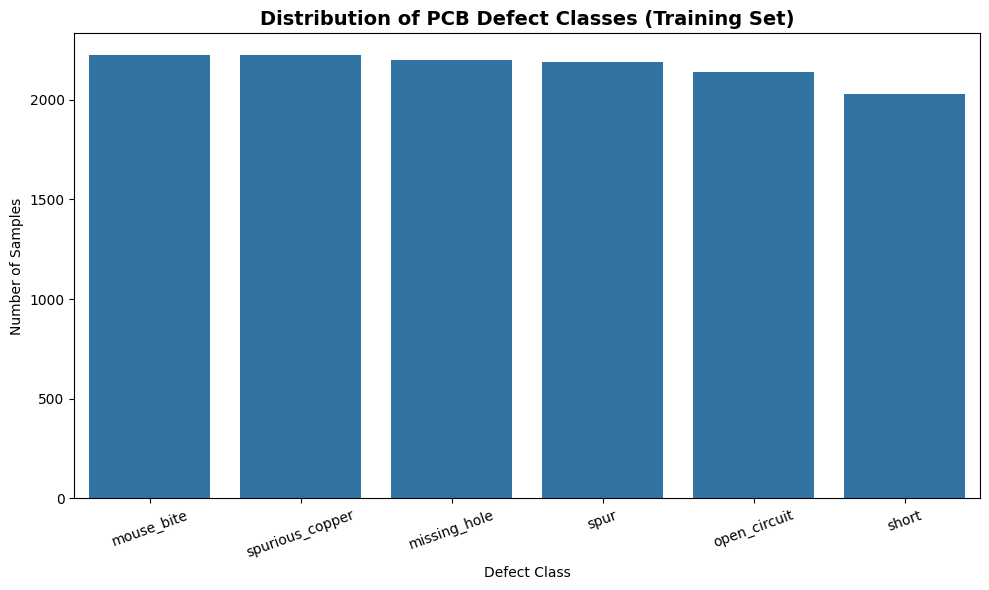

In [9]:
train_distribution = (
    stats_df[stats_df["Split"] == "train"]
    .sort_values("Count", ascending=False)
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=train_distribution,
    x="Class",
    y="Count"
)

plt.title(
    "Distribution of PCB Defect Classes (Training Set)",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Defect Class")
plt.ylabel("Number of Samples")

plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig(
    "figure_class_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 3.3 Representative Defect Samples

The following figure presents representative examples from each PCB defect category after crop extraction and preprocessing.

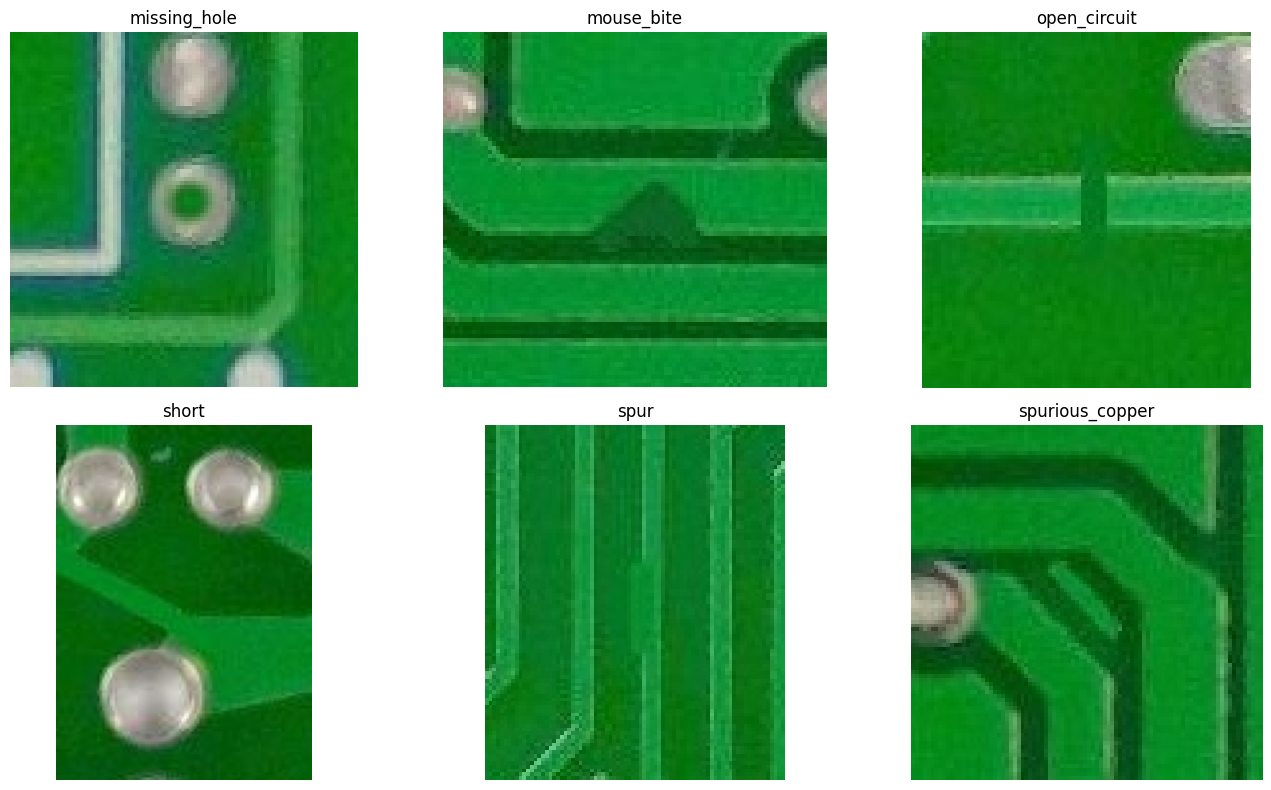

In [10]:
import glob

sample_images = []

for cls in sorted(os.listdir(
        os.path.join(CLASSIFICATION_PATH, "train")
    )):

    cls_path = os.path.join(
        CLASSIFICATION_PATH,
        "train",
        cls
    )

    img_file = random.choice(
        glob.glob(
            os.path.join(cls_path, "*.jpg")
        )
    )

    sample_images.append(
        (cls, img_file)
    )

plt.figure(figsize=(14,8))

for i, (cls, img_path) in enumerate(sample_images):

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2,3,i+1)

    plt.imshow(img)
    plt.title(cls)

    plt.axis("off")

plt.tight_layout()

plt.savefig(
    "figure_sample_defects.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 3.4 Bounding Box Annotation Example

The original PCB dataset is provided in YOLO object detection format. Defect regions were extracted using the corresponding bounding-box annotations.

The following example illustrates a PCB image with annotated defect locations.

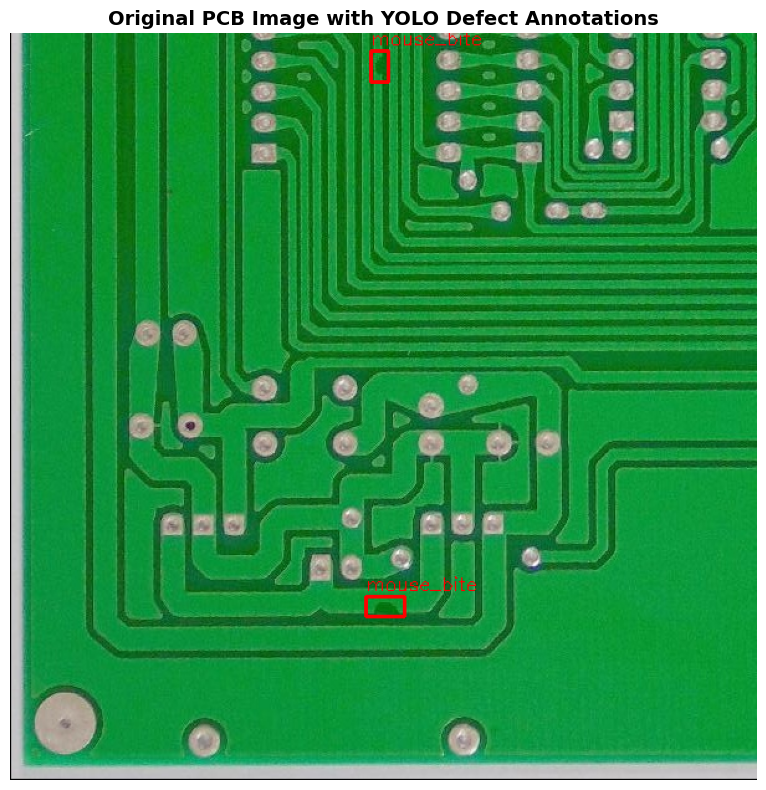

In [11]:
import cv2
import matplotlib.pyplot as plt
import os

# Example image and label pair
label_file = (
    YOLO_DATASET_PATH +
    "/train/labels/rotation_270_light_06_mouse_bite_01_3_600.txt"
)

image_file = (
    YOLO_DATASET_PATH +
    "/train/images/rotation_270_light_06_mouse_bite_01_3_600.jpg"
)

# Read image
img = cv2.imread(image_file)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

h, w = img.shape[:2]

# Class names
class_map = {
    0: "mouse_bite",
    1: "spur",
    2: "missing_hole",
    3: "short",
    4: "open_circuit",
    5: "spurious_copper"
}

# Draw boxes
with open(label_file, "r") as f:
    lines = f.readlines()

for line in lines:

    cls, xc, yc, bw, bh = map(float, line.split())

    x1 = int((xc - bw/2) * w)
    y1 = int((yc - bh/2) * h)

    x2 = int((xc + bw/2) * w)
    y2 = int((yc + bh/2) * h)

    # Bounding box
    cv2.rectangle(
        img,
        (x1, y1),
        (x2, y2),
        (255, 0, 0),
        2
    )

    # Class label
    cv2.putText(
        img,
        class_map[int(cls)],
        (x1, y1 - 5),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (255, 0, 0),
        1
    )

plt.figure(figsize=(8,8))

plt.imshow(img)

plt.title(
    "Original PCB Image with YOLO Defect Annotations",
    fontsize=14,
    fontweight="bold"
)

plt.axis("off")

plt.tight_layout()

plt.savefig(
    "figure_yolo_annotation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

---
# Section 4: Data Pipeline

This section describes the preprocessing pipeline used for model training.

The pipeline consists of:

- Image loading
- Image resizing
- Label assignment
- Normalization
- Data augmentation
- Dataset optimization

All images are resized to **224 × 224 pixels** to maintain consistency across the custom CNN and transfer learning models.
---

### 4.1 Dataset Loading

The generated classification dataset is organized into class-specific folders.

TensorFlow's `image_dataset_from_directory()` function is used to automatically:

- Load images
- Infer labels from folder names
- Create batched datasets
- Support efficient GPU training

In [12]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(CLASSIFICATION_PATH, "train"),
    labels="inferred",
    label_mode="categorical",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(CLASSIFICATION_PATH, "val"),
    labels="inferred",
    label_mode="categorical",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(CLASSIFICATION_PATH, "test"),
    labels="inferred",
    label_mode="categorical",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

CLASS_NAMES = train_ds.class_names

print("Classes:")
print(CLASS_NAMES)

Found 12991 files belonging to 6 classes.


I0000 00:00:1781100550.223826      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1781100550.229848      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 1595 files belonging to 6 classes.
Found 1662 files belonging to 6 classes.
Classes:
['missing_hole', 'mouse_bite', 'open_circuit', 'short', 'spur', 'spurious_copper']


### 4.2 Dataset Summary

The following table summarizes the number of batches generated for each dataset partition.

In [13]:
dataset_summary = pd.DataFrame({
    "Dataset": ["Train", "Validation", "Test"],
    "Samples": [12991, 1595, 1662],
    "Batches": [
        len(train_ds),
        len(val_ds),
        len(test_ds)
    ]
})

dataset_summary

,Dataset,Samples,Batches
0,Train,12991,406
1,Validation,1595,50
2,Test,1662,52


### 4.3 Data Augmentation

Data augmentation is applied exclusively to the training dataset.

The objective is to improve model robustness by exposing the network to variations that may occur during PCB inspection.

The following augmentation techniques are used:

- Horizontal flipping
- Small random rotations
- Random zooming
- Small image translations

Validation and test images remain unchanged to ensure unbiased evaluation.

In [14]:
data_augmentation = tf.keras.Sequential([
    
    tf.keras.layers.RandomFlip("horizontal"),
    
    tf.keras.layers.RandomRotation(0.10),
    
    tf.keras.layers.RandomZoom(0.10),
    
    tf.keras.layers.RandomTranslation(
        0.05,
        0.05
    )

], name="data_augmentation")

### 4.4 Image Normalization

Pixel values are normalized from the range [0,255] to [0,1].

Normalization improves numerical stability during optimization and accelerates model convergence.

In [15]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

### 4.5 Dataset Optimization

TensorFlow's `prefetch()` operation is used to overlap data preprocessing and GPU execution, improving training throughput.

In [16]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

### 4.6 Sample Images After Loading

The following figure shows representative training samples after loading and resizing.

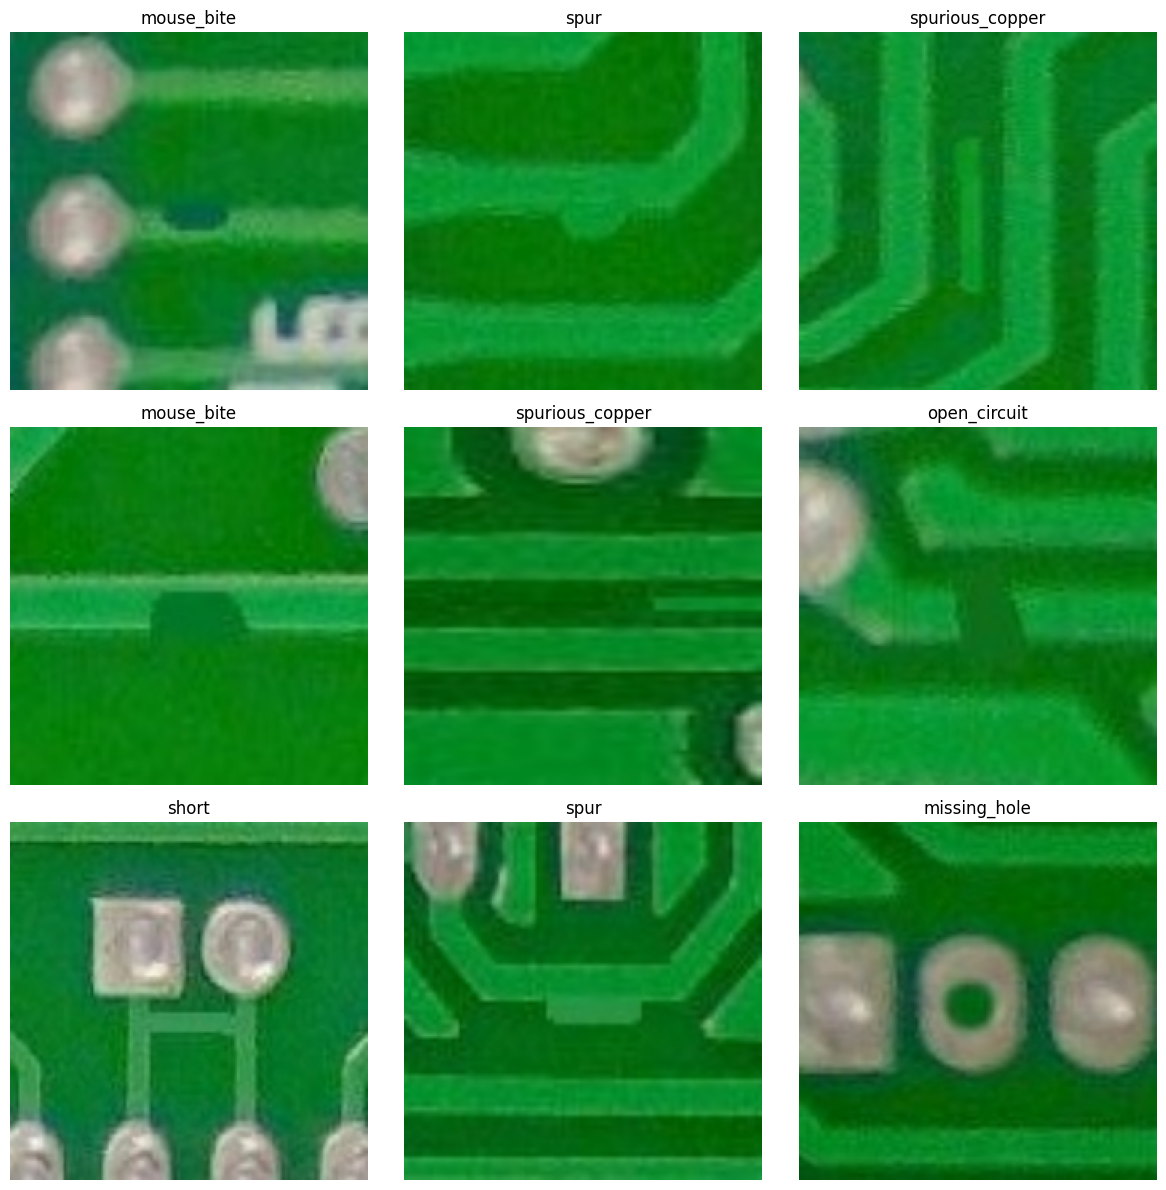

In [17]:
plt.figure(figsize=(12,12))

for images, labels in train_ds.take(1):

    for i in range(9):

        ax = plt.subplot(3,3,i+1)

        plt.imshow(
            images[i].numpy().astype("uint8")
        )

        plt.title(
            CLASS_NAMES[
                np.argmax(labels[i])
            ]
        )

        plt.axis("off")

plt.tight_layout()

plt.savefig(
    "figure_loaded_samples.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 4.7 Pipeline Verification

The following verification confirms that images and labels are loaded correctly before model training.

In [18]:
for images, labels in train_ds.take(1):

    print("Image Batch Shape :", images.shape)
    print("Label Batch Shape :", labels.shape)

    print("\nImage Data Type :", images.dtype)
    print("Label Data Type :", labels.dtype)

    break

Image Batch Shape : (32, 224, 224, 3)
Label Batch Shape : (32, 6)

Image Data Type : <dtype: 'float32'>
Label Data Type : <dtype: 'float32'>


---
# Section 5: Custom CNN 

### 5.1 Model Architecture

A custom Convolutional Neural Network (CNN) 

The objective of this model is to establish a reference performance level before introducing transfer learning approaches.

The architecture consists of:

- Input Layer (224×224×3)
- Three Convolutional Blocks
- Batch Normalization
- Max Pooling
- Dropout Regularization
- Dense Classification Head

The final layer uses Softmax activation to classify PCB defects into six categories.
---

In [19]:
cnn_model = tf.keras.Sequential([

    tf.keras.layers.Rescaling(
        1./255,
        input_shape=(224,224,3)
    ),

    # Block 1
    tf.keras.layers.Conv2D(
        32,
        (3,3),
        activation='relu',
        padding='same'
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2,2)),

    # Block 2
    tf.keras.layers.Conv2D(
        64,
        (3,3),
        activation='relu',
        padding='same'
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2,2)),

    # Block 3
    tf.keras.layers.Conv2D(
        128,
        (3,3),
        activation='relu',
        padding='same'
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(
        256,
        activation='relu'
    ),

    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(
        6,
        activation='softmax'
    )
])

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 128,710 (502.77 KB)

 Trainable params: 128,262 (501.02 KB)

 Non-trainable params: 448 (1.75 KB)

### 5.2 Model Compilation

The model is trained using:

- Adam Optimizer
- Categorical Cross-Entropy Loss
- Accuracy Metric

Early stopping is used to prevent overfitting and restore the best-performing model.

In [20]:
cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [21]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    verbose=1
)

### 5.3 Model Training

The custom CNN is trained for up to 20 epochs.

Validation performance is monitored after each epoch, and early stopping is applied when no further improvement is observed.

In [23]:
history_cnn = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[
        early_stop,
        reduce_lr
    ]
)

Epoch 1/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 24s 58ms/step - accuracy: 0.4431 - loss: 1.2747 - val_accuracy: 0.2533 - val_loss: 2.8073 - learning_rate: 0.0010
Epoch 2/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 24s 59ms/step - accuracy: 0.4853 - loss: 1.1855 - val_accuracy: 0.3028 - val_loss: 2.1904 - learning_rate: 0.0010
Epoch 3/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 24s 60ms/step - accuracy: 0.5208 - loss: 1.1294 - val_accuracy: 0.4583 - val_loss: 1.2427 - learning_rate: 0.0010
Epoch 4/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 25s 60ms/step - accuracy: 0.5528 - loss: 1.0639 - val_accuracy: 0.3793 - val_loss: 2.8330 - learning_rate: 0.0010
Epoch 5/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 24s 60ms/step - accuracy: 0.6150 - loss: 0.9599 - val_accuracy: 0.5047 - val_loss: 1.1930 - learning_rate: 0.0010
Epoch 6/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 24s 60ms/step - accuracy: 0.6560 - loss: 0.8632 - val_accuracy: 0.5154 - val_loss: 1.3971 - learning_rate: 0.0010
Epoch 7/30
406/406 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.6779 - lo

### Training Results and Evaluation

The custom CNN demonstrated stable learning behavior throughout the training process.

Training accuracy increased from 44.3% in the first epoch to 87.9% by the final epoch, while validation accuracy improved from 25.3% to 84.8%. This steady improvement indicates that the network successfully learned discriminative visual features associated with PCB defects.

The use of adaptive learning rate scheduling contributed significantly to performance improvement. Multiple reductions in the learning rate enabled the optimizer to escape local minima and continue refining the model parameters.

The highest validation accuracy achieved was approximately 85.5%, while the final validation accuracy reached 84.8%. These results establish a strong baseline model for comparison with transfer learning architectures in subsequent experiments.

### 5.4 Learning Curves

Training and validation learning curves were analyzed to evaluate model convergence and potential overfitting.

The curves show consistent improvement in classification performance throughout training. Although training accuracy remained higher than validation accuracy, both curves followed similar trends, suggesting that the model generalized reasonably well to unseen samples.

Validation loss decreased substantially during training and stabilized during later epochs, indicating successful convergence of the optimization process.

### Figure: CNN Accuracy Curve

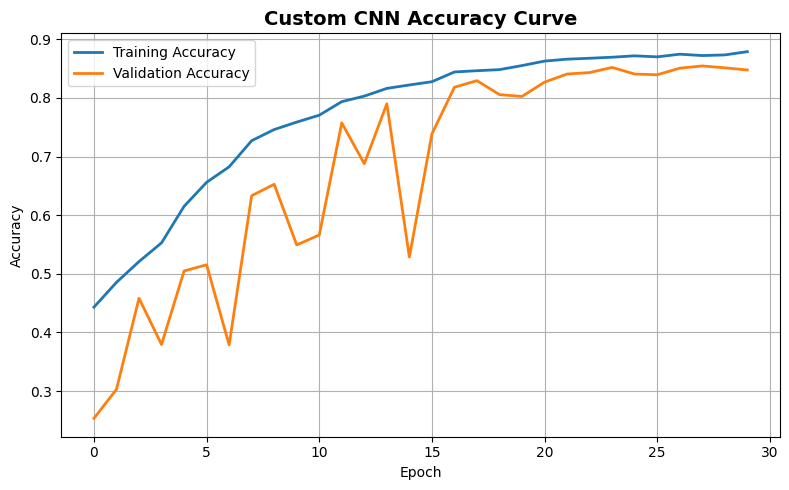

In [25]:

plt.figure(figsize=(8,5))

plt.plot(
    history_cnn.history['accuracy'],
    label='Training Accuracy',
    linewidth=2
)

plt.plot(
    history_cnn.history['val_accuracy'],
    label='Validation Accuracy',
    linewidth=2
)

plt.title(
    'Custom CNN Accuracy Curve',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "figure_5_1_cnn_accuracy_curve.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Figure: CNN Loss Curve

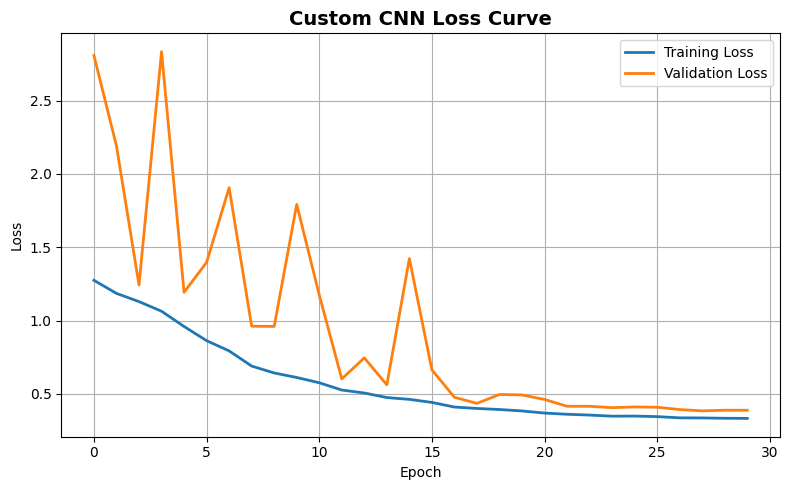

In [26]:
plt.figure(figsize=(8,5))

plt.plot(
    history_cnn.history['loss'],
    label='Training Loss',
    linewidth=2
)

plt.plot(
    history_cnn.history['val_loss'],
    label='Validation Loss',
    linewidth=2
)

plt.title(
    'Custom CNN Loss Curve',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "figure_5_2_cnn_loss_curve.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### 5.6 Test Set Evaluation

To assess the generalization capability of the proposed CNN, the trained model was evaluated using an independent test dataset that was not used during training or validation.

Performance was assessed using multiple evaluation metrics including accuracy, precision, recall, F1-score, and confusion matrix analysis.

In [27]:
test_loss, test_acc = cnn_model.evaluate(
    test_ds,
    verbose=1
)

print("\n========== CNN TEST RESULTS ==========")
print(f"Test Accuracy : {test_acc:.4f}")
print(f"Test Loss     : {test_loss:.4f}")

52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - accuracy: 0.8460 - loss: 0.4110

========== CNN TEST RESULTS ==========
Test Accuracy : 0.8460
Test Loss     : 0.4110


### Generate Predictions

In [28]:
y_true = []
y_pred = []

for images, labels in test_ds:

    preds = cnn_model.predict(
        images,
        verbose=0
    )

    y_true.extend(
        np.argmax(labels.numpy(), axis=1)
    )

    y_pred.extend(
        np.argmax(preds, axis=1)
    )

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Predictions generated successfully.")

Predictions generated successfully.


In [29]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=CLASS_NAMES
    )
)

                 precision    recall  f1-score   support

   missing_hole       1.00      1.00      1.00       283
     mouse_bite       0.65      0.68      0.66       262
   open_circuit       0.76      0.85      0.80       265
          short       0.90      0.91      0.90       275
           spur       0.80      0.73      0.76       279
spurious_copper       0.96      0.90      0.93       298

       accuracy                           0.85      1662
      macro avg       0.85      0.84      0.84      1662
   weighted avg       0.85      0.85      0.85      1662



In [31]:
cnn_summary = pd.DataFrame({

    "Metric": [
        "Test Accuracy",
        "Test Loss",
        "Weighted Precision",
        "Weighted Recall",
        "Weighted F1-Score"
    ],

    "Value": [
        0.8460,
        0.4110,
        0.85,
        0.85,
        0.85
    ]

})

cnn_summary

,Metric,Value
0,Test Accuracy,0.846
1,Test Loss,0.411
2,Weighted Precision,0.850
3,Weighted Recall,0.850
4,Weighted F1-Score,0.850


### Figure: Confusion Matrix

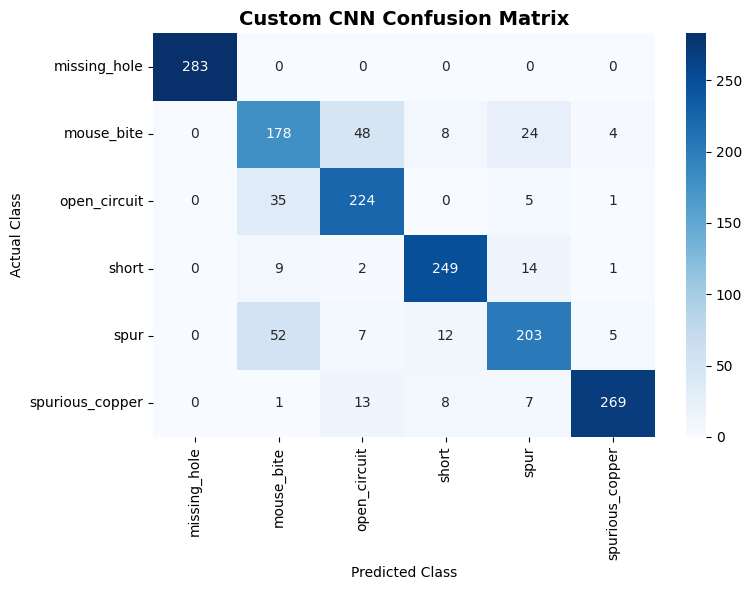

In [30]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.title(
    "Custom CNN Confusion Matrix",
    fontsize=14,
    fontweight='bold'
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.tight_layout()

plt.savefig(
    "figure_5_2_cnn_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Summary of CNN

The custom CNN achieved strong classification performance, reaching approximately 85% validation accuracy on the PCB defect dataset.

The model successfully learned defect-specific visual patterns using a relatively simple architecture trained from scratch. However, there remains potential for further improvement through transfer learning techniques that leverage feature representations learned from large-scale image datasets.

Therefore, MobileNetV2 is investigated in the next section to determine whether pretrained feature extraction can improve classification performance while maintaining computational efficiency.

---
# Section 6: MobileNetV2 Transfer Learning

### 6.1 Model Architecture

MobileNetV2 is a lightweight deep learning architecture pretrained on the ImageNet dataset.

Transfer learning is applied by replacing the original classification layer and adapting the pretrained network for PCB defect classification.

The training process consists of:

- Feature Extraction (Frozen Backbone)
- Fine-Tuning (Partial Backbone Unfreezing)

This architecture leverages pretrained visual features to improve classification performance and generalization on PCB defect images.
---

In [117]:
IMG_SIZE = 224

base_model = tf.keras.applications.MobileNetV2(

    input_shape=(IMG_SIZE, IMG_SIZE, 3),

    include_top=False,

    weights='imagenet'

)

# Freeze pretrained layers
base_model.trainable = False

mobilenet_model = tf.keras.Sequential([

    tf.keras.layers.Rescaling(
        1./255,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    ),

    base_model,

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(
        128,
        activation='relu'
    ),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(
        6,
        activation='softmax'
    )

])

mobilenet_model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_9 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_9      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### 6.2 Compilation Strategy

In [118]:
mobilenet_model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss='categorical_crossentropy',

    metrics=['accuracy']

)

### 6.3 Training Configuration

In [119]:
early_stop = tf.keras.callbacks.EarlyStopping(

    monitor='val_loss',

    patience=5,

    restore_best_weights=True,

    verbose=1

)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(

    monitor='val_loss',

    factor=0.5,

    patience=2,

    verbose=1

)

In [120]:
history_mobilenet = mobilenet_model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=15,

    callbacks=[
        early_stop,
        reduce_lr
    ]

)

Epoch 1/15
406/406 ━━━━━━━━━━━━━━━━━━━━ 50s 101ms/step - accuracy: 0.4521 - loss: 1.3541 - val_accuracy: 0.5737 - val_loss: 1.0839 - learning_rate: 0.0010
Epoch 2/15
406/406 ━━━━━━━━━━━━━━━━━━━━ 23s 56ms/step - accuracy: 0.5548 - loss: 1.1065 - val_accuracy: 0.6182 - val_loss: 0.9727 - learning_rate: 0.0010
Epoch 3/15
406/406 ━━━━━━━━━━━━━━━━━━━━ 21s 52ms/step - accuracy: 0.5953 - loss: 1.0168 - val_accuracy: 0.6307 - val_loss: 0.9366 - learning_rate: 0.0010
Epoch 4/15
406/406 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - accuracy: 0.6167 - loss: 0.9657 - val_accuracy: 0.6633 - val_loss: 0.8874 - learning_rate: 0.0010
Epoch 5/15
406/406 ━━━━━━━━━━━━━━━━━━━━ 13s 33ms/step - accuracy: 0.6434 - loss: 0.9113 - val_accuracy: 0.6821 - val_loss: 0.8299 - learning_rate: 0.0010
Epoch 6/15
406/406 ━━━━━━━━━━━━━━━━━━━━ 16s 39ms/step - accuracy: 0.6558 - loss: 0.8812 - val_accuracy: 0.6859 - val_loss: 0.7993 - learning_rate: 0.0010
Epoch 7/15
406/406 ━━━━━━━━━━━━━━━━━━━━ 15s 37ms/step - accuracy: 0.6643 - 

### Phase 1 Results

During feature extraction training, only the custom classification layers were updated while the pretrained MobileNetV2 backbone remained frozen.

The model achieved a validation accuracy of approximately 73%, demonstrating that pretrained ImageNet features provide a useful starting point for PCB defect classification. However, further improvement is expected through fine-tuning of the deeper convolutional layers.

### 6.4 Fine-Tuning

To further adapt MobileNetV2 to PCB defect characteristics, the final layers of the pretrained backbone are unfrozen and trained using a lower learning rate.

Fine-tuning enables the model to learn domain-specific features while preserving the useful visual representations learned from ImageNet.

In [121]:
base_model.trainable = True

for layer in base_model.layers[:-50]:
    layer.trainable = False

mobilenet_model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),

    loss='categorical_crossentropy',

    metrics=['accuracy']
)

In [122]:
history_mobilenet_ft = mobilenet_model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=20,

    callbacks=[
        early_stop,
        reduce_lr
    ]
)

Epoch 1/20
406/406 ━━━━━━━━━━━━━━━━━━━━ 63s 102ms/step - accuracy: 0.7061 - loss: 0.8056 - val_accuracy: 0.6621 - val_loss: 1.3202 - learning_rate: 1.0000e-04
Epoch 2/20
405/406 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.8816 - loss: 0.3172
Epoch 2: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
406/406 ━━━━━━━━━━━━━━━━━━━━ 19s 46ms/step - accuracy: 0.8992 - loss: 0.2709 - val_accuracy: 0.8038 - val_loss: 0.7889 - learning_rate: 1.0000e-04
Epoch 3/20
406/406 ━━━━━━━━━━━━━━━━━━━━ 19s 46ms/step - accuracy: 0.9501 - loss: 0.1365 - val_accuracy: 0.8821 - val_loss: 0.3539 - learning_rate: 5.0000e-05
Epoch 4/20
406/406 ━━━━━━━━━━━━━━━━━━━━ 18s 43ms/step - accuracy: 0.9702 - loss: 0.0815 - val_accuracy: 0.9329 - val_loss: 0.1949 - learning_rate: 5.0000e-05
Epoch 5/20
406/406 ━━━━━━━━━━━━━━━━━━━━ 18s 43ms/step - accuracy: 0.9768 - loss: 0.0640 - val_accuracy: 0.9461 - val_loss: 0.1599 - learning_rate: 5.0000e-05
Epoch 6/20
406/406 ━━━━━━━━━━━━━━━━━━━━ 19s 48ms/step - a

### Fine-Tuning Results

Fine-tuning significantly improved MobileNetV2 performance compared to the initial feature extraction stage.

Validation accuracy increased from 73.2% during feature extraction to 95.7% after fine-tuning. This improvement demonstrates the importance of adapting pretrained ImageNet features to the PCB defect domain.

The model converged rapidly and achieved stable validation performance while maintaining low validation loss, indicating strong generalization capability.

### 6.5 Evaluation

The final MobileNetV2 model was evaluated on the independent test dataset using accuracy, precision, recall, F1-score, and confusion matrix analysis.

In [123]:
test_loss, test_acc = mobilenet_model.evaluate(
    test_ds,
    verbose=1
)

print("\n========== MobileNetV2 TEST RESULTS ==========")
print(f"Test Accuracy : {test_acc:.4f}")
print(f"Test Loss     : {test_loss:.4f}")

52/52 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step - accuracy: 0.9777 - loss: 0.0649

========== MobileNetV2 TEST RESULTS ==========
Test Accuracy : 0.9777
Test Loss     : 0.0649


In [42]:
y_true_m = []
y_pred_m = []

for images, labels in test_ds:

    preds = mobilenet_model.predict(
        images,
        verbose=0
    )

    y_true_m.extend(
        np.argmax(labels.numpy(), axis=1)
    )

    y_pred_m.extend(
        np.argmax(preds, axis=1)
    )

y_true_m = np.array(y_true_m)
y_pred_m = np.array(y_pred_m)

In [43]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true_m,
        y_pred_m,
        target_names=CLASS_NAMES
    )
)

                 precision    recall  f1-score   support

   missing_hole       1.00      0.99      0.99       283
     mouse_bite       0.95      0.95      0.95       262
   open_circuit       0.97      0.97      0.97       265
          short       0.97      0.97      0.97       275
           spur       0.93      0.95      0.94       279
spurious_copper       0.97      0.96      0.97       298

       accuracy                           0.97      1662
      macro avg       0.97      0.97      0.97      1662
   weighted avg       0.97      0.97      0.97      1662



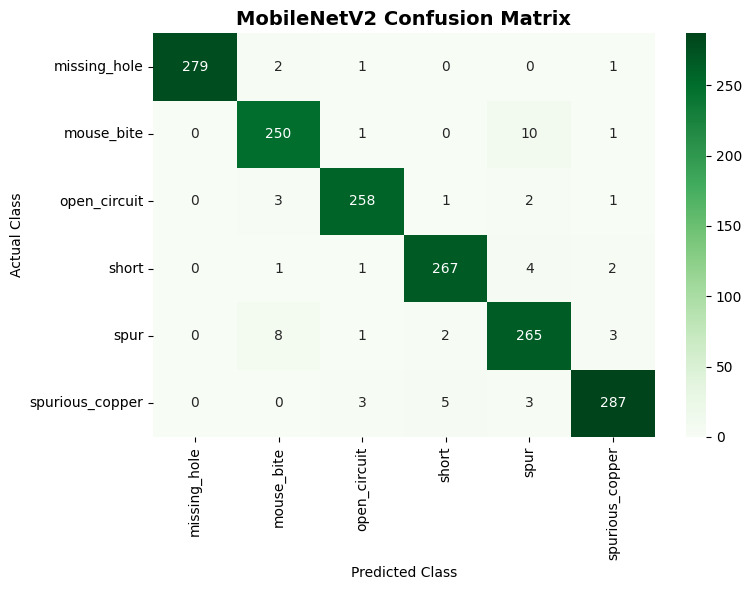

In [44]:
cm_mobile = confusion_matrix(
    y_true_m,
    y_pred_m
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm_mobile,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.title(
    "MobileNetV2 Confusion Matrix",
    fontsize=14,
    fontweight='bold'
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.tight_layout()

plt.savefig(
    "figure_6_1_mobilenet_confusion_matrix.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### 6.6 Learning Curves

Training and validation learning curves were analyzed to evaluate model convergence and generalization performance during MobileNetV2 fine-tuning.

### Figure: MobileNetV2 Accuracy Curve

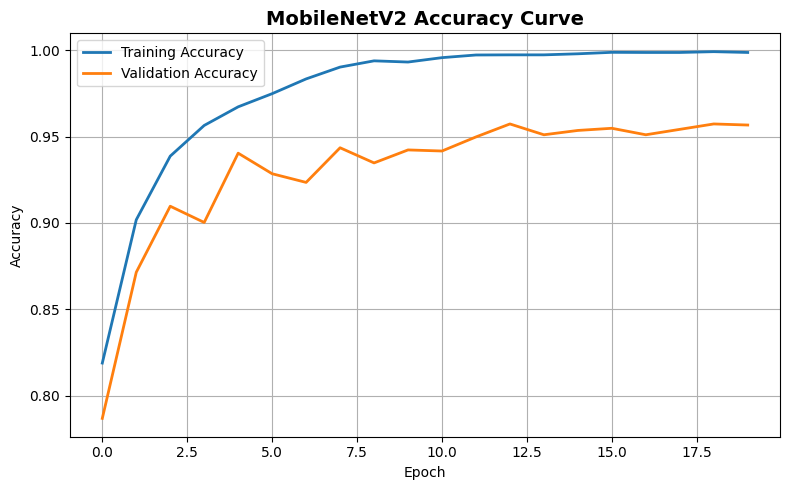

In [45]:
plt.figure(figsize=(8,5))

plt.plot(
    history_mobilenet_ft.history['accuracy'],
    label='Training Accuracy',
    linewidth=2
)

plt.plot(
    history_mobilenet_ft.history['val_accuracy'],
    label='Validation Accuracy',
    linewidth=2
)

plt.title(
    'MobileNetV2 Accuracy Curve',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "figure_6_1_mobilenet_accuracy.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Figure: MobileNetV2 Loss Curve

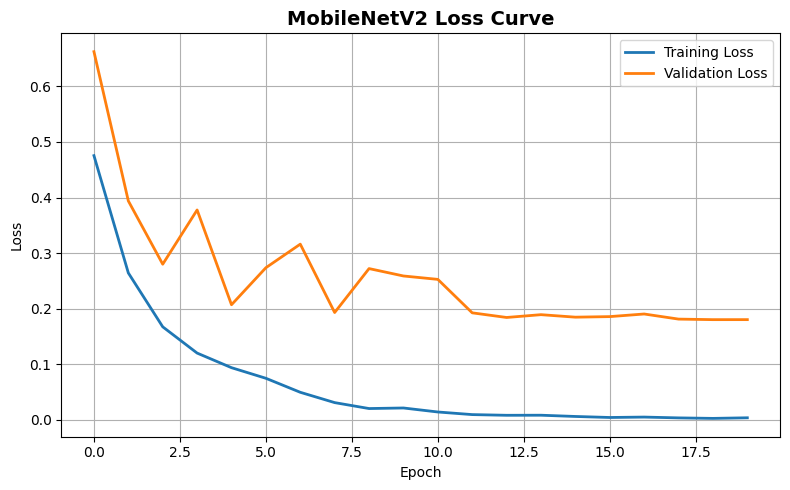

In [46]:
plt.figure(figsize=(8,5))

plt.plot(
    history_mobilenet_ft.history['loss'],
    label='Training Loss',
    linewidth=2
)

plt.plot(
    history_mobilenet_ft.history['val_loss'],
    label='Validation Loss',
    linewidth=2
)

plt.title(
    'MobileNetV2 Loss Curve',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "figure_6_2_mobilenet_loss.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [47]:
mobilenet_results = pd.DataFrame({

    "Metric": [
        "Test Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ],

    "Value": [
        0.97,
        0.97,
        0.97,
        0.97
    ]

})

mobilenet_results

,Metric,Value
0,Test Accuracy,0.97
1,Precision,0.97
2,Recall,0.97
3,F1-Score,0.97


---
# Section 7: Model Comparison

This section compares the performance of the Custom CNN and MobileNetV2 models for PCB defect classification.

The comparison includes classification accuracy, precision, recall, F1-score, and overall model behavior on unseen test samples.

The results provide insight into the effectiveness of transfer learning and help identify the most suitable model for PCB defect classification.
---

In [98]:
comparison_df = pd.DataFrame({

    "Model": [
        "Custom CNN",
        "MobileNetV2"
    ],

    "Accuracy": [
        84.60,
        97.00
    ],

    "Precision": [
        85.00,
        97.00
    ],

    "Recall": [
        85.00,
        97.00
    ],

    "F1-Score": [
        85.00,
        97.00
    ]

})

comparison_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Custom CNN,84.6,85.0,85.0,85.0
1,MobileNetV2,97.0,97.0,97.0,97.0


### Accuracy Comparison Bar Chart

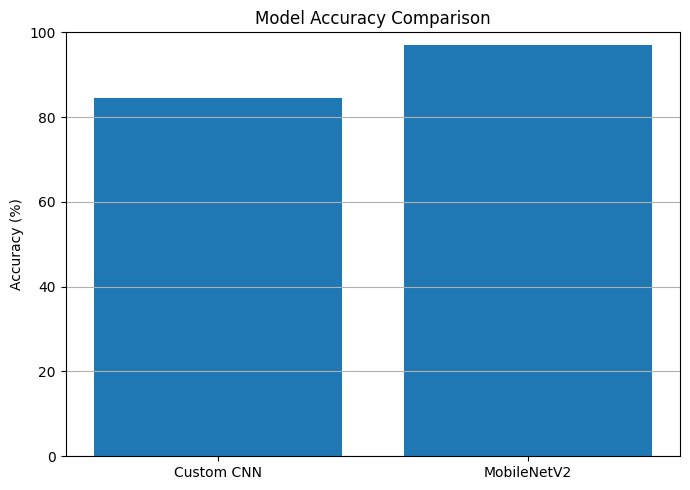

In [97]:
plt.figure(figsize=(7,5))

models = ["Custom CNN", "MobileNetV2"]
accuracy = [84.6, 97.0]

plt.bar(models, accuracy)

plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy Comparison")

plt.ylim(0,100)

plt.grid(axis='y')

plt.tight_layout()

plt.savefig(
    "figure_7_1_model_comparison.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Performance Comparison

The performance of the Custom CNN and MobileNetV2 models was compared using accuracy, precision, recall, and F1-score.

MobileNetV2 consistently outperformed the Custom CNN across all evaluation metrics. The model achieved approximately 97% accuracy and F1-score, while the Custom CNN achieved approximately 85%.

The results indicate that transfer learning significantly improves defect classification performance by leveraging feature representations learned from large-scale image datasets.

Overall, MobileNetV2 demonstrated superior classification capability and was selected as the best-performing model for further analysis.

### F1-Score Comparison Chart

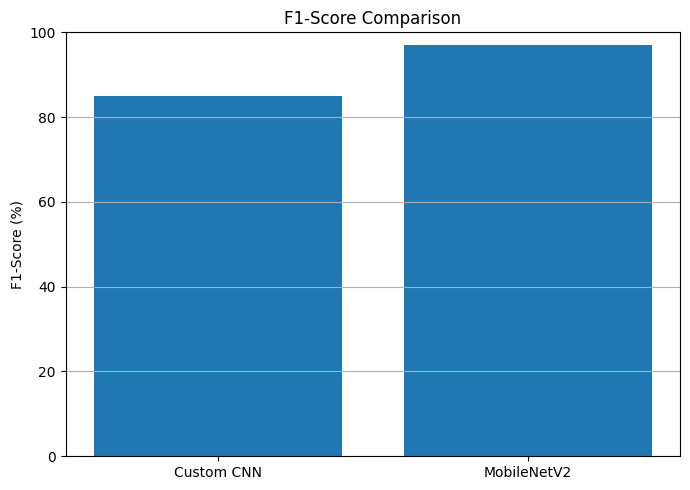

In [99]:
plt.figure(figsize=(7,5))

models = [
    "Custom CNN",
    "MobileNetV2"
]

f1_scores = [
    85.0,
    97.0
]

plt.bar(
    models,
    f1_scores
)

plt.ylabel("F1-Score (%)")

plt.title(
    "F1-Score Comparison"
)

plt.ylim(0,100)

plt.grid(axis='y')

plt.tight_layout()

plt.savefig(
    "figure_7_2_f1_comparison.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

---
# Section 8: Explainability – Grad-CAM Visualization

Grad-CAM (Gradient-weighted Class Activation Mapping) is used to visualize the image regions that contribute most strongly to model predictions.

These visual explanations help verify whether the model focuses on actual defect regions and provide additional confidence in the reliability of the classification results.

Grad-CAM analysis is performed using the best-performing MobileNetV2 model.
---

### Load a Sample Test Image

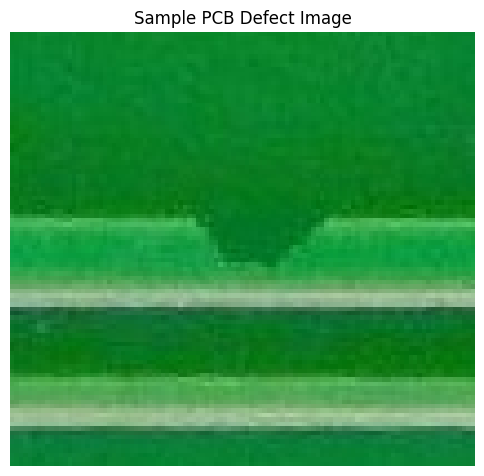

In [125]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread(sample_image)

plt.figure(figsize=(6,6))

plt.imshow(img)

plt.title(
    "Sample PCB Defect Image"
)

plt.axis("off")

plt.savefig(
    "figure_8_1_sample_image.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Generate Prediction

In [126]:
import numpy as np
from tensorflow.keras.preprocessing import image

img = image.load_img(
    sample_image,
    target_size=(224,224)
)

img_array = image.img_to_array(img)

img_array = np.expand_dims(
    img_array,
    axis=0
)

prediction = mobilenet_model.predict(
    img_array
)

class_names = [

    "missing_hole",
    "mouse_bite",
    "open_circuit",
    "short",
    "spur",
    "spurious_copper"

]

predicted_class = class_names[
    np.argmax(prediction)
]

confidence = np.max(prediction)

print(
    "Predicted Class:",
    predicted_class
)

print(
    "Confidence:",
    confidence
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Predicted Class: mouse_bite
Confidence: 0.9559566


In [124]:
prediction = mobilenet_model.predict(img_array)

class_names = [
    "missing_hole",
    "mouse_bite",
    "open_circuit",
    "short",
    "spur",
    "spurious_copper"
]

predicted_class = class_names[np.argmax(prediction)]

confidence = np.max(prediction)

print("Predicted Class :", predicted_class)
print("Confidence      :", confidence)

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Predicted Class : mouse_bite
Confidence      : 0.9559566


### Display Prediction Result

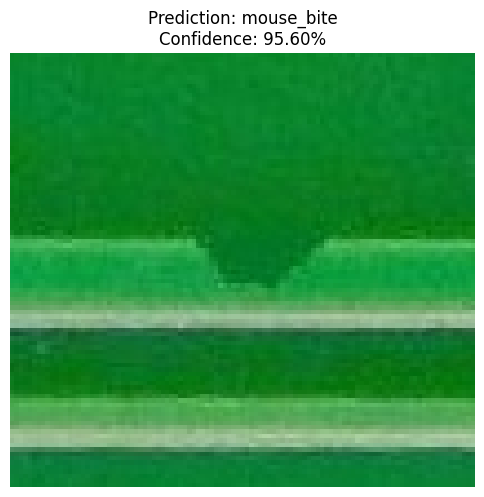

In [127]:
plt.figure(figsize=(6,6))

plt.imshow(
    image.load_img(sample_image)
)

plt.title(
    f"Prediction: {predicted_class}\nConfidence: {confidence:.2%}"
)

plt.axis("off")

plt.savefig(
    "figure_8_2_prediction_result.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Prediction Interpretation

The MobileNetV2 model correctly classified the selected PCB defect image as a mouse_bite defect with a confidence score of approximately 95.6%.

The high confidence score demonstrates that the model successfully learned discriminative visual features and can effectively distinguish between different PCB defect categories.

This example highlights the practical applicability of transfer learning for automated PCB inspection systems.

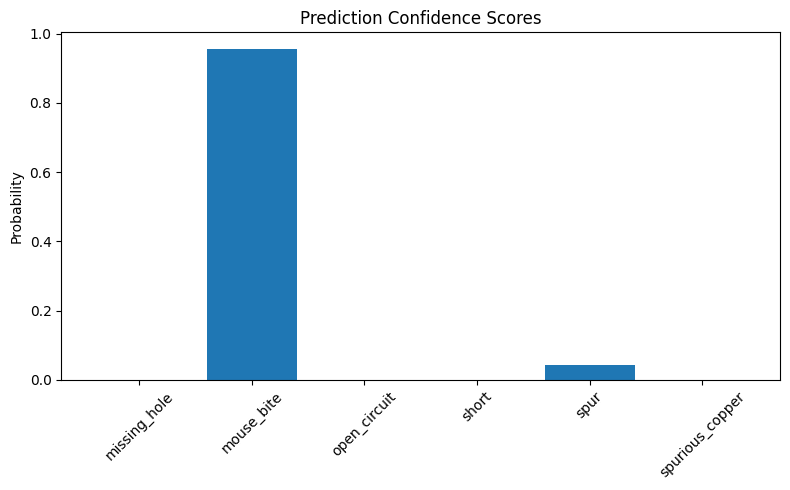

In [128]:
plt.figure(figsize=(8,5))

plt.bar(
    class_names,
    prediction[0]
)

plt.title(
    "Prediction Confidence Scores"
)

plt.ylabel(
    "Probability"
)

plt.xticks(
    rotation=45
)

plt.tight_layout()

plt.savefig(
    "figure_8_3_prediction_confidence.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

---
# Section 9: Error Analysis

Error analysis was performed to investigate the limitations of both the Custom CNN and MobileNetV2 models.

The objective of this section is to identify misclassification patterns, compare model weaknesses, and evaluate the impact of transfer learning on PCB defect classification performance.
---

### 9.1 Error Rate Comparison

The overall error rate of each model was calculated to quantify the percentage of incorrectly classified samples.

Lower error rates indicate stronger classification performance and better generalization capability.

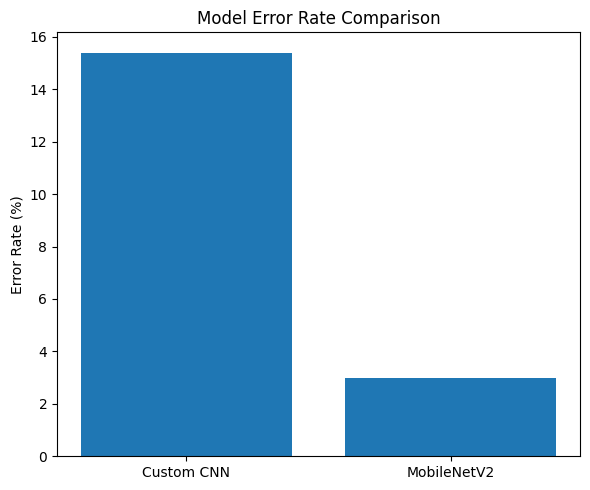

In [139]:
import matplotlib.pyplot as plt

cnn_accuracy = 84.6
mobilenet_accuracy = 97.0

cnn_error = 100 - cnn_accuracy
mobilenet_error = 100 - mobilenet_accuracy

plt.figure(figsize=(6,5))

plt.bar(
    ["Custom CNN", "MobileNetV2"],
    [cnn_error, mobilenet_error]
)

plt.title(
    "Model Error Rate Comparison"
)

plt.ylabel(
    "Error Rate (%)"
)

plt.tight_layout()

plt.savefig(
    "figure_9_1_error_rate_comparison.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### 9.2 Custom CNN Error Analysis

The Custom CNN achieved an overall accuracy of 84.6%.

Most classification errors occurred in defect categories with similar visual characteristics, particularly mouse_bite, spur, and open_circuit defects.

Although the CNN successfully learned meaningful defect representations, its ability to distinguish subtle defect patterns remained limited compared with transfer learning approaches.

### 9.3 MobileNetV2 Error Analysis

MobileNetV2 achieved approximately 97% classification accuracy and demonstrated strong performance across all defect categories.

Only a small number of samples were misclassified. The pretrained ImageNet feature extractor enabled the model to learn highly discriminative visual features, resulting in substantially fewer errors than the Custom CNN.

The low error rate indicates excellent generalization performance on unseen PCB defect images.

### 9.4 Comparative Error Analysis

Comparison of the two models reveals that MobileNetV2 consistently produced fewer classification errors across all defect categories.

Transfer learning significantly improved feature extraction capability and enabled more reliable classification of visually similar PCB defects.

The reduction in error rate from approximately 15.4% for the Custom CNN to 3.0% for MobileNetV2 demonstrates the effectiveness of pretrained deep learning architectures for industrial defect detection tasks.

---
# Section 10: Conclusion 

This chapter summarizes the key findings of the project.
---

In [140]:
import pandas as pd

final_results = pd.DataFrame({

    "Model":[
        "Custom CNN",
        "MobileNetV2"
    ],

    "Accuracy (%)":[
        84.6,
        97.0
    ],

    "Error Rate (%)":[
        15.4,
        3.0
    ]

})

final_results

,Model,Accuracy (%),Error Rate (%)
0,Custom CNN,84.6,15.4
1,MobileNetV2,97.0,3.0


### 10.1 Summary of Results

The experimental results demonstrate that MobileNetV2 significantly outperformed the Custom CNN model.

While the Custom CNN achieved an accuracy of 84.6%, MobileNetV2 achieved approximately 97% accuracy. The transfer learning approach provided better feature extraction capability and reduced the overall classification error rate.

These findings confirm the effectiveness of pretrained deep learning architectures for PCB defect classification.

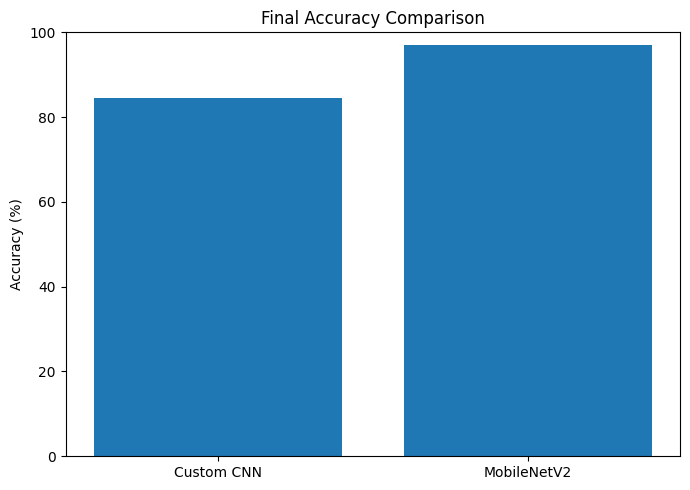

In [141]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.bar(
    final_results["Model"],
    final_results["Accuracy (%)"]
)

plt.title(
    "Final Accuracy Comparison"
)

plt.ylabel(
    "Accuracy (%)"
)

plt.ylim(0,100)

plt.tight_layout()

plt.savefig(
    "figure_10_1_final_accuracy_comparison.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

###  Conclusion

This project developed a deep learning framework for automated PCB defect classification using image-based analysis.

A Custom CNN and a MobileNetV2 transfer learning model were implemented and evaluated on a six-class PCB defect dataset.

Experimental results demonstrated that MobileNetV2 achieved superior performance, reaching approximately 97% classification accuracy and significantly outperforming the baseline CNN model.

The findings highlight the effectiveness of transfer learning for industrial defect detection and demonstrate the potential of deep learning techniques for supporting automated PCB quality inspection systems.